<a id="top"></a>
# Chapter 9 — Analysing configurations

**Reverse Monte Carlo with RMCProfile — from the pair distribution function to a refined box** · chapter 9 of 10

[◀ 8 Magnetic, EXAFS and diffuse scattering](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb) · [Contents of the book](README.md) · [10 Benchmarks and the ecosystem ▶](RMCProfile_10_Benchmarks_and_Ecosystem.ipynb)

**In this chapter**

- [§35 A refined box is a statistical object](#sec-35)
- [§36 Coordination numbers and bond lengths](#sec-36)
- [§37 Bond angles and displacement clouds](#sec-37)
- [§38 Ensembles: several fits are better than one](#sec-38)

All chapters: [0](RMCProfile_00_Introduction.ipynb) · [1](RMCProfile_01_Total_Scattering_and_the_PDF.ipynb) · [2](RMCProfile_02_The_RMC_Algorithm.ipynb) · [3](RMCProfile_03_Starting_Configurations.ipynb) · [4](RMCProfile_04_Fitting_Neutron_Data.ipynb) · [5](RMCProfile_05_Xray_and_Bragg.ipynb) · [6](RMCProfile_06_Constraints_and_Potentials.ipynb) · [7](RMCProfile_07_Corrections.ipynb) · [8](RMCProfile_08_Magnetic_EXAFS_Diffuse.ipynb) · [9](RMCProfile_09_Analysing_Configurations.ipynb) · [10](RMCProfile_10_Benchmarks_and_Ecosystem.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–40), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import tempfile
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in RMCPROFILE_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("RMCPROFILE_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "rmcprofile_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import rmcprofile_tools as rt
import rmclite as rl
import upstream_adapter as ua

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 21}               # figure numbers run through the whole book
PKG = rt.find_package()                     # the user's RMCProfile package, or None
WORK = tempfile.mkdtemp(prefix="rmcbook-")  # scratch directory for the runs of this chapter

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def skip_without_package(what="this cell"):
    '''True (and a [SKIP] line) when RMCProfile is not installed; the cell then does nothing.'''
    if PKG is None:
        print(f"[SKIP] {what} — set RMCPROFILE_HOME to your RMCProfile_package directory")
        return True
    return False

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("rmcprofile-skill", rt.__version__, "| numpy", np.__version__, "| RMCProfile package:",
      (PKG.platform + " build") if PKG else "not set", "| chapter 9")
t_chapter_start = time.time()

rmcprofile-skill 0.5.1 | numpy 2.5.2 | RMCProfile package: windows build | chapter 9


<a id="sec-35"></a>

## 35. A refined box is a statistical object

Chapter 2 showed that RMC reproduces the pair distribution, not the coordinates; chapter 4
refined a box against synthetic data. What one reads off such a box must therefore be
*distributions* — coordination numbers, bond lengths, bond angles, displacement clouds —
never the position of a particular atom. This chapter takes the boxes this book can make
without the package (an `rmclite` fit of the chapter-4 synthetic data) and shows the four
analyses the toolkit offers, each checked against the answer the synthetic truth knows.

In [2]:
NACL = [("Na", 0, 0, 0), ("Na", .5, .5, 0), ("Na", .5, 0, .5), ("Na", 0, .5, .5),
        ("Cl", .5, 0, 0), ("Cl", 0, .5, 0), ("Cl", 0, 0, .5), ("Cl", .5, .5, .5)]
A = 5.64
cfg = rt.build_configuration((A, A, A, 90, 90, 90), NACL, (3, 3, 3), title="NaCl 3x3x3")
rng = np.random.default_rng(0)
truth = rl.Box.from_rmc6f(cfg)
truth.frac = (truth.frac + rng.normal(0, 0.05, truth.frac.shape) / cfg.cell[0]) % 1.0
r, g_truth, G_truth = rl.synth_targets(truth, rmax=8.0, dr=0.02, noise=0.0, rng=rng)

def fit_box(seed, moves=6000):
    box = rl.Box.from_rmc6f(cfg)
    eng = rl.RmcLite(box, rmax=8.0, dr=0.02, targets=[rl.PartialTarget(lab, r, g_truth[lab], 0.2) for lab in g_truth],
                     constraints=[rl.ClosestApproach({"Na-Na": 3.0, "Na-Cl": 2.2, "Cl-Cl": 3.0})],
                     max_move={"Na": 0.05, "Cl": 0.05}, seed=seed)
    c0 = eng.chi2
    eng.run(moves)
    return box.to_rmc6f(cfg), c0, eng.chi2

fitted, c0, c1 = fit_box(1)
print(f"rmclite fit from the ideal lattice: chi2 {c0:.3g} -> {c1:.3g}")
check("a refined box to analyse (chi2 fell by > 95 %)", c1 < 0.05 * c0)

rmclite fit from the ideal lattice: chi2 1.98e+06 -> 266
[PASS] a refined box to analyse (chi2 fell by > 95 %)


True

<a id="sec-36"></a>

## 36. Coordination numbers and bond lengths

`coordination(cfg, A, B, rmax)` counts the B atoms within `rmax` of every A atom and
returns the per-atom counts and their histogram — in rock salt every Na keeps six Cl
neighbours within 3.2 Å whatever the thermal motion, so the histogram is a single bar.
The bond-length distribution is the Na–Cl partial itself, weighted by the shell; its mean
and width are the two numbers a neutron PDF is usually asked for.

fitted box: Na coordination histogram {6: 108} | truth: {6: 108}
Na–Cl bond: fitted 2.822 ± 0.074 Å, truth 2.822 ± 0.072 Å


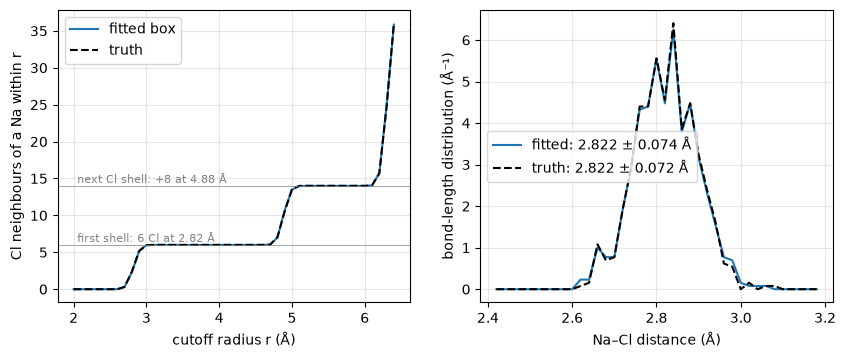

[PASS] every Na keeps six Cl neighbours in the refined box — {6: 108}
[PASS] the mean Na–Cl bond length is the truth's within 0.01 Å — 2.822 vs 2.822 Å
[PASS] the bond-length width is the truth's within 30 % — 0.074 vs 0.072 Å


True

In [3]:
counts, hist = rt.coordination(fitted, "Na", "Cl", rmax=3.2)
counts_t, hist_t = rt.coordination(truth.to_rmc6f(cfg), "Na", "Cl", rmax=3.2)
print("fitted box: Na coordination histogram", hist, "| truth:", hist_t)
r_f, g_f = rt.partial_gr(fitted, rmax=8.0, dr=0.02)
shell = (r_f > 2.4) & (r_f < 3.2)
wgt = g_f["Na-Cl"][shell] * r_f[shell] ** 2
d_mean = np.sum(wgt * r_f[shell]) / np.sum(wgt)
d_std = np.sqrt(np.sum(wgt * (r_f[shell] - d_mean) ** 2) / np.sum(wgt))
wgt_t = g_truth["Na-Cl"][shell] * r[shell] ** 2
t_mean = np.sum(wgt_t * r[shell]) / np.sum(wgt_t)
t_std = np.sqrt(np.sum(wgt_t * (r[shell] - t_mean) ** 2) / np.sum(wgt_t))
print(f"Na–Cl bond: fitted {d_mean:.3f} ± {d_std:.3f} Å, truth {t_mean:.3f} ± {t_std:.3f} Å")

# the running coordination number n(r): Cl neighbours of a Na within r, averaged over the Na atoms
cutoffs = np.arange(2.0, 6.5, 0.02)
n_fit = np.array([np.mean(rt.coordination(fitted, "Na", "Cl", rmax=rc)[0]) for rc in cutoffs[::5]])
n_tru = np.array([np.mean(rt.coordination(truth.to_rmc6f(cfg), "Na", "Cl", rmax=rc)[0]) for rc in cutoffs[::5]])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(cutoffs[::5], n_fit, "C0", label="fitted box")
axes[0].plot(cutoffs[::5], n_tru, "k--", label="truth")
for n_shell, lab in ((6, "first shell: 6 Cl at 2.82 Å"), (14, "next Cl shell: +8 at 4.88 Å")):
    axes[0].axhline(n_shell, color="gray", lw=0.5); axes[0].text(2.05, n_shell + 0.4, lab, fontsize=8, color="gray")
axes[0].set_xlabel("cutoff radius r (Å)"); axes[0].set_ylabel("Cl neighbours of a Na within r"); axes[0].legend(loc="upper left")
axes[1].plot(r_f[shell], wgt / wgt.sum() / 0.02, "C0", label=f"fitted: {d_mean:.3f} ± {d_std:.3f} Å")
axes[1].plot(r[shell], wgt_t / wgt_t.sum() / 0.02, "k--", label=f"truth: {t_mean:.3f} ± {t_std:.3f} Å")
axes[1].set_xlabel("Na–Cl distance (Å)"); axes[1].set_ylabel("bond-length distribution (Å⁻¹)"); axes[1].legend()
show(fig)
caption("Left: the running coordination number of Na — Cl neighbours within a cutoff radius, "
        "averaged over the 108 Na atoms — for the refined box and the truth: a plateau at 6 "
        "across the whole first shell (the histogram at 3.2 Å is a single bar, 6 : 108), the "
        "step to 14 at the next Cl shell (4.88 Å) and the rise into the 24 at 6.3 Å. Right: the first-shell bond-length distribution, r²-weighted "
        "from the Na–Cl partial, with its mean and width for both boxes.")
check("every Na keeps six Cl neighbours in the refined box", hist == {6: 108}, str(hist))
check("the mean Na–Cl bond length is the truth's within 0.01 Å", abs(d_mean - t_mean) < 0.01, f"{d_mean:.3f} vs {t_mean:.3f} Å")
check("the bond-length width is the truth's within 30 %", abs(d_std - t_std) < 0.3 * t_std, f"{d_std:.3f} vs {t_std:.3f} Å")

<a id="sec-37"></a>

## 37. Bond angles and displacement clouds

`bond_angles(cfg, A, B, C, rmax)` returns every B–A–C angle whose two arms are within
`rmax`; in rock salt the Cl–Na–Cl angles are 90° and 180° and thermal motion spreads them
by a few degrees. `fold_to_unit_cell` collapses the supercell onto one cell so that the
displacement cloud of a site can be seen and measured.

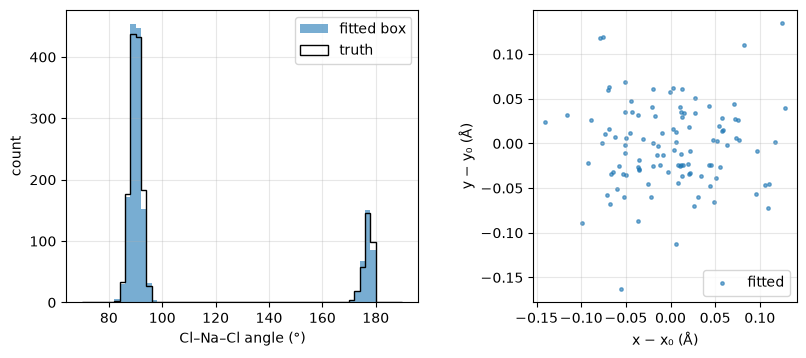

[PASS] the 90° peak is where it should be — median 89.9°
[PASS] the angle spread of the fit matches the truth's within 30 % — 2.08° vs 2.02°
[PASS] the Na displacement cloud has a thermal width — 0.057 Å (truth 0.056 Å)


True

In [4]:
ang = rt.bond_angles(fitted, "Na", "Cl", "Cl", rmax=3.2)
ang_t = rt.bond_angles(truth.to_rmc6f(cfg), "Na", "Cl", "Cl", rmax=3.2)
# displacement of every atom from its own ideal site (same atom order in both boxes), in Å
def displacements(box_cfg):
    d = box_cfg.frac - cfg.frac
    d -= np.round(d)
    return d @ cfg.lattice
na = displacements(fitted)[fitted.atoms == "Na"]
na_t = displacements(truth.to_rmc6f(cfg))[cfg.atoms == "Na"]
frac_cell, idx = rt.fold_to_unit_cell(fitted)              # the same atoms folded into one cell (for the record)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].hist(ang, bins=np.arange(70, 191, 2), alpha=0.6, label="fitted box")
axes[0].hist(ang_t, bins=np.arange(70, 191, 2), histtype="step", color="k", label="truth")
axes[0].set_xlabel("Cl–Na–Cl angle (°)"); axes[0].set_ylabel("count"); axes[0].legend()
axes[1].scatter(na[:, 0], na[:, 1], s=6, alpha=0.6, label="fitted")
axes[1].set_xlabel("x − x₀ (Å)"); axes[1].set_ylabel("y − y₀ (Å)"); axes[1].set_aspect("equal"); axes[1].legend()
show(fig)
caption("Left: the Cl–Na–Cl angle distribution of the refined box (filled) and of the truth "
        "box (line): two peaks at 90° and 180° broadened by the thermal displacements. Right: "
        "the displacement of each of the 108 Na atoms from its ideal site, projected on ab — "
        "the displacement cloud of the Na site.")
near90 = ang[(ang > 70) & (ang < 110)]
check("the 90° peak is where it should be", abs(np.median(near90) - 90) < 1.0, f"median {np.median(near90):.1f}°")
check("the angle spread of the fit matches the truth's within 30 %", abs(near90.std() - ang_t[(ang_t > 70) & (ang_t < 110)].std()) < 0.3 * ang_t[(ang_t > 70) & (ang_t < 110)].std(),
      f"{near90.std():.2f}° vs {ang_t[(ang_t > 70) & (ang_t < 110)].std():.2f}°")
check("the Na displacement cloud has a thermal width", 0.03 < na[:, 0].std() < 0.12, f"{na[:, 0].std():.3f} Å (truth {na_t[:, 0].std():.3f} Å)")

<a id="sec-38"></a>

## 38. Ensembles: several fits are better than one

One fitted box carries the statistical noise of its 216 atoms. Refining several boxes with
different seeds and averaging their partials reduces that noise — the average partial is
closer to the target than any single fit, and the spread between fits is the honest error
bar of anything read off a box. RMCProfile users do the same with several independent runs.

rms deviation from the target: single fits [0.098 0.115 0.114 0.11 ] | ensemble mean 0.081


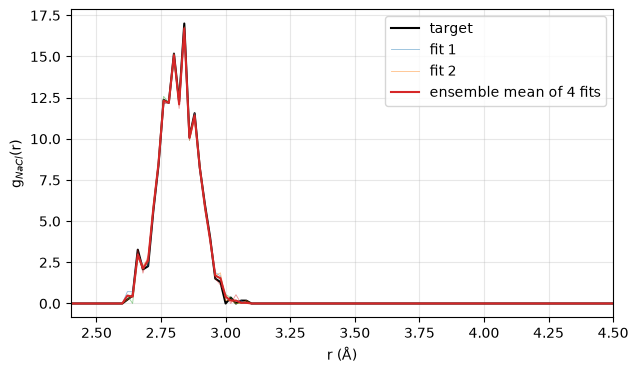

[PASS] the ensemble mean is closer to the target than every single fit — 0.081 vs best single 0.098


True

In [5]:
boxes = [fitted] + [fit_box(seed, moves=4000)[0] for seed in (2, 3, 4)]
parts = [rt.partial_gr(b, rmax=8.0, dr=0.02)[1]["Na-Cl"] for b in boxes]
mean_part = np.mean(parts, axis=0)
dev_single = [np.sqrt(np.mean((p - g_truth["Na-Cl"]) ** 2)) for p in parts]
dev_mean = np.sqrt(np.mean((mean_part - g_truth["Na-Cl"]) ** 2))
print("rms deviation from the target: single fits", np.round(dev_single, 3), "| ensemble mean", round(dev_mean, 3))
fig, ax = plt.subplots()
ax.plot(r, g_truth["Na-Cl"], "k", label="target")
for k, p in enumerate(parts):
    ax.plot(r, p, lw=0.6, alpha=0.5, label=f"fit {k + 1}" if k < 2 else None)
ax.plot(r, mean_part, "C3", lw=1.5, label="ensemble mean of 4 fits")
ax.set_xlim(2.4, 4.5); ax.set_xlabel("r (Å)"); ax.set_ylabel("g$_{NaCl}$(r)"); ax.legend()
show(fig)
caption("Four rmclite fits of the same synthetic data from different seeds (thin) and their "
        "mean (red) against the target (black): averaging over an ensemble beats any single "
        "box, and the spread between boxes is the error bar.")
check("the ensemble mean is closer to the target than every single fit", dev_mean < min(dev_single),
      f"{dev_mean:.3f} vs best single {min(dev_single):.3f}")

### Exercises for chapter 9

**9.1** Compute the Na–Na coordination within 4.3 Å (the second shell) of the fitted box.
How many neighbours, and is the histogram still a single bar?

**9.2** Export the fitted box to XYZ and CIF and confirm that the CIF's cell is the
supercell (16.92 Å) while `average_cell` gives 5.64 Å.

In [6]:
# 9.1 — twelve Na–Na neighbours at a/sqrt2 = 3.99 A; thermal motion does not break the shell
counts2, hist2 = rt.coordination(fitted, "Na", "Na", rmax=4.3)
print("Na–Na within 4.3 Å:", hist2)
check("9.1 twelve Na–Na second-shell neighbours for every Na", hist2 == {12: 108}, str(hist2))

# 9.2
rt.export_xyz(fitted, os.path.join(WORK, "fitted.xyz"))
rt.export_cif(fitted, os.path.join(WORK, "fitted.cif"))
with open(os.path.join(WORK, "fitted.cif"), encoding="utf-8") as f:
    cif = f.read()
check("9.2 the CIF cell is the supercell and the average cell the unit cell",
      "_cell_length_a   16.920000" in cif and abs(rt.average_cell(fitted)[0] - 5.64) < 1e-9)

Na–Na within 4.3 Å: {12: 108}
[PASS] 9.1 twelve Na–Na second-shell neighbours for every Na — {12: 108}
[PASS] 9.2 the CIF cell is the supercell and the average cell the unit cell


True

In [7]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 9 — checks passed : {_CHECKS['pass']}")
print(f"chapter 9 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 9 — checks passed : 10
chapter 9 — checks failed : 0
wall time                 : 24 s
Every quantitative claim in this notebook was verified in this run.
